In [19]:
#############################################################
# SECTION 0: SETUP - Installations and Imports
#############################################################

# Install necessary libraries
!pip install optuna hyperopt scikit-optimize --quiet

# Import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

# Import scikit-learn modules
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes
# Import Hyperopt
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# Import Optuna
import optuna

# Import scikit-optimize
from skopt import BayesSearchCV

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [20]:
#############################################################
# SECTION 1: DATA PREPARATION
#############################################################

print("============================================================")
print("SECTION 1: DATA PREPARATION")
print("============================================================\n")

# Load the Diabetes dataset
diab_data = load_diabetes()
X = diab_data.data
y = diab_data.target
feature_names = diab_data.feature_names

# Convert to pandas DataFrame for better visualization
df_diab = pd.DataFrame(X, columns=feature_names)
df_diab['target'] = y

print("Diabetes dataset shape:", df_diab.shape)
print("\nTarget Statistics:")
print(df_diab['target'].describe())

# Split the data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)



SECTION 1: DATA PREPARATION

Diabetes dataset shape: (442, 11)

Target Statistics:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

Training set shape: (309, 10)
Test set shape: (133, 10)


In [21]:
#############################################################
# SECTION 2: MODEL DEFINITION
#############################################################

print("\n============================================================")
print("SECTION 2: MODEL DEFINITION")
print("============================================================\n")

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)



SECTION 2: MODEL DEFINITION



In [22]:

#############################################################
# SECTION 3: HYPERPARAMETER SEARCH SPACES
#############################################################

print("\n============================================================")
print("SECTION 3: HYPERPARAMETER SEARCH SPACES")
print("============================================================\n")

# Define hyperparameter space for Grid Search and Random Search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

# Define hyperparameter space for Hyperopt
space = {
    'n_estimators': hp.choice('n_estimators', [50, 100, 200]),
    'max_depth': hp.choice('max_depth', [None, 10, 20, 30]),
    'min_samples_split': hp.choice('min_samples_split', [2, 5, 10]),
}

# Define hyperparameter space for Optuna and scikit-optimize (Bayesian Search)
bayesian_search_space = {
    'n_estimators': (50, 200),          # Integer
    'max_depth': (10, 30),              # Integer
    'min_samples_split': (2, 10),       # Integer
}




SECTION 3: HYPERPARAMETER SEARCH SPACES



In [23]:
#############################################################
# SECTION 4: GRID SEARCH
#############################################################

print("\n============================================================")
print("SECTION 4: GRID SEARCH")
print("============================================================\n")

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    verbose=1
)

# Fit GridSearchCV
t0 = time()
grid_search.fit(X_train, y_train)
print("Time taken:", time() - t0, "seconds")

print("Best parameters found by Grid Search:")
print(grid_search.best_params_)
print("Best cross-validation RMSE:", np.sqrt(-grid_search.best_score_))

# Evaluate on test set
y_pred = grid_search.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
print("Test set RMSE:", test_rmse)
print("Test set R2 Score:", test_r2)




SECTION 4: GRID SEARCH

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Time taken: 67.26002931594849 seconds
Best parameters found by Grid Search:
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validation RMSE: 58.75270771226171
Test set RMSE: 52.79391588876905
Test set R2 Score: 0.4836905049117274


In [24]:
#############################################################
# SECTION 5: RANDOM SEARCH
#############################################################

print("\n============================================================")
print("SECTION 5: RANDOM SEARCH")
print("============================================================\n")

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1
)

# Fit RandomizedSearchCV
t0 = time()
random_search.fit(X_train, y_train)
print("Time taken:", time() - t0, "seconds")

print("Best parameters found by Random Search:")
print(random_search.best_params_)
print("Best cross-validation RMSE:", np.sqrt(-random_search.best_score_))

# Evaluate on test set
y_pred = random_search.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
print("Test set RMSE:", test_rmse)
print("Test set R2 Score:", test_r2)




SECTION 5: RANDOM SEARCH

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Time taken: 51.556227684020996 seconds
Best parameters found by Random Search:
{'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 30}
Best cross-validation RMSE: 58.75270771226171
Test set RMSE: 52.79391588876905
Test set R2 Score: 0.4836905049117274


In [28]:
#############################################################
# SECTION 6: HYPEROPT
#############################################################
from numpy.random import default_rng

print("\n============================================================")
print("SECTION 6: HYPEROPT")
print("============================================================\n")

# Objective function for Hyperopt
def objective(params):
    clf = RandomForestRegressor(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        random_state=42,
        n_jobs=-1
    )
    # Perform cross-validation
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    return {'loss': -score, 'status': STATUS_OK}

# Initialize Trials object
trials = Trials()

t0 = time()
# Run Hyperopt
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=default_rng(42)
)
print("Time taken:", time() - t0, "seconds")

# Map Hyperopt's choice indices to actual values
hyperopt_params = {
    'n_estimators': [50, 100, 200][best['n_estimators']],
    'max_depth': [None, 10, 20, 30][best['max_depth']],
    'min_samples_split': [2, 5, 10][best['min_samples_split']],
}

print("Best parameters found by Hyperopt:")
print(hyperopt_params)
print("Best cross-validation RMSE:", np.sqrt(-min([trial['loss'] for trial in trials.results])))

# Train the model with best Hyperopt parameters
best_hyperopt_rf = RandomForestRegressor(
    n_estimators=hyperopt_params['n_estimators'],
    max_depth=hyperopt_params['max_depth'],
    min_samples_split=hyperopt_params['min_samples_split'],
    random_state=42,
    n_jobs=-1
)

best_hyperopt_rf.fit(X_train, y_train)

# Evaluate on test set
y_pred = best_hyperopt_rf.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
print("Test set RMSE:", test_rmse)
print("Test set R2 Score:", test_r2)




SECTION 6: HYPEROPT

100%|██████████| 50/50 [01:22<00:00,  1.66s/trial, best loss: 3451.880663522456]
Time taken: 82.81487107276917 seconds
Best parameters found by Hyperopt:
{'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 10}
Best cross-validation RMSE: nan
Test set RMSE: 52.79391588876905
Test set R2 Score: 0.4836905049117275


In [29]:
#############################################################
# SECTION 7: OPTUNA
#############################################################

print("\n============================================================")
print("SECTION 7: OPTUNA")
print("============================================================\n")

# Define objective function for Optuna
def optuna_objective(trial):
    # Suggest values for hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_categorical('max_depth', [None, 10, 20, 30])
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    # Initialize the model with suggested hyperparameters
    clf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
    )

    # Perform cross-validation
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()

    return -score  # Optuna minimizes by default

# Create a study object
study = optuna.create_study(direction='minimize')
t0 = time()
study.optimize(optuna_objective, n_trials=50)
print("Time taken:", time() - t0, "seconds")

print("Best parameters found by Optuna:")
print(study.best_params)
print("Best cross-validation RMSE:", np.sqrt(study.best_value))

# Train the model with best Optuna parameters
best_optuna_rf = RandomForestRegressor(
    n_estimators=study.best_params['n_estimators'],
    max_depth=study.best_params['max_depth'],
    min_samples_split=study.best_params['min_samples_split'],
    random_state=42,
    n_jobs=-1
)

best_optuna_rf.fit(X_train, y_train)

# Evaluate on test set
y_pred = best_optuna_rf.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
print("Test set RMSE:", test_rmse)
print("Test set R2 Score:", test_r2)



[I 2025-01-06 06:21:46,775] A new study created in memory with name: no-name-d38e7d1e-98af-46fe-825d-6fb1f0fe1ca6



SECTION 7: OPTUNA



[I 2025-01-06 06:21:48,972] Trial 0 finished with value: 3503.972310695378 and parameters: {'n_estimators': 175, 'max_depth': 20, 'min_samples_split': 6}. Best is trial 0 with value: 3503.972310695378.
[I 2025-01-06 06:21:51,155] Trial 1 finished with value: 3519.0198642292753 and parameters: {'n_estimators': 171, 'max_depth': None, 'min_samples_split': 4}. Best is trial 0 with value: 3503.972310695378.
[I 2025-01-06 06:21:52,507] Trial 2 finished with value: 3504.1673043984165 and parameters: {'n_estimators': 101, 'max_depth': 30, 'min_samples_split': 6}. Best is trial 0 with value: 3503.972310695378.
[I 2025-01-06 06:21:58,285] Trial 3 finished with value: 3513.7959753132745 and parameters: {'n_estimators': 187, 'max_depth': 20, 'min_samples_split': 4}. Best is trial 0 with value: 3503.972310695378.
[I 2025-01-06 06:22:02,021] Trial 4 finished with value: 3510.4264993534334 and parameters: {'n_estimators': 187, 'max_depth': 30, 'min_samples_split': 7}. Best is trial 0 with value: 350

Time taken: 72.06913876533508 seconds
Best parameters found by Optuna:
{'n_estimators': 71, 'max_depth': None, 'min_samples_split': 10}
Best cross-validation RMSE: 58.47940311890149
Test set RMSE: 52.978450631370464
Test set R2 Score: 0.4800748021228006


In [30]:
#############################################################
# SECTION 8: BAYESIAN SEARCH (scikit-optimize)
#############################################################

print("\n============================================================")
print("SECTION 8: BAYESIAN SEARCH (scikit-optimize)")
print("============================================================\n")

# Initialize BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    search_spaces=bayesian_search_space,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# Fit BayesSearchCV
t0 = time()
bayes_search.fit(X_train, y_train)
print("Time taken:", time() - t0, "seconds")

print("Best parameters found by Bayesian Search:")
print(bayes_search.best_params_)
print("Best cross-validation RMSE:", np.sqrt(-bayes_search.best_score_))

# Evaluate on test set
y_pred = bayes_search.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
print("Test set RMSE:", test_rmse)
print("Test set R2 Score:", test_r2)



SECTION 8: BAYESIAN SEARCH (scikit-optimize)

Time taken: 167.91247963905334 seconds
Best parameters found by Bayesian Search:
OrderedDict([('max_depth', 10), ('min_samples_split', 10), ('n_estimators', 70)])
Best cross-validation RMSE: 58.4424332037078
Test set RMSE: 52.89075921716957
Test set R2 Score: 0.4817945671198053



SECTION 9: COMPARISON OF METHODS

Summary of Hyperparameter Optimization Methods:
            Method  Best CV RMSE  Test RMSE  Test R2 Score
0      Grid Search     58.752708  52.793916       0.483691
1    Random Search     58.752708  52.793916       0.483691
2         Hyperopt           NaN  52.793916       0.483691
3           Optuna     58.479403  52.978451       0.480075
4  Bayesian Search     58.442433  52.890759       0.481795


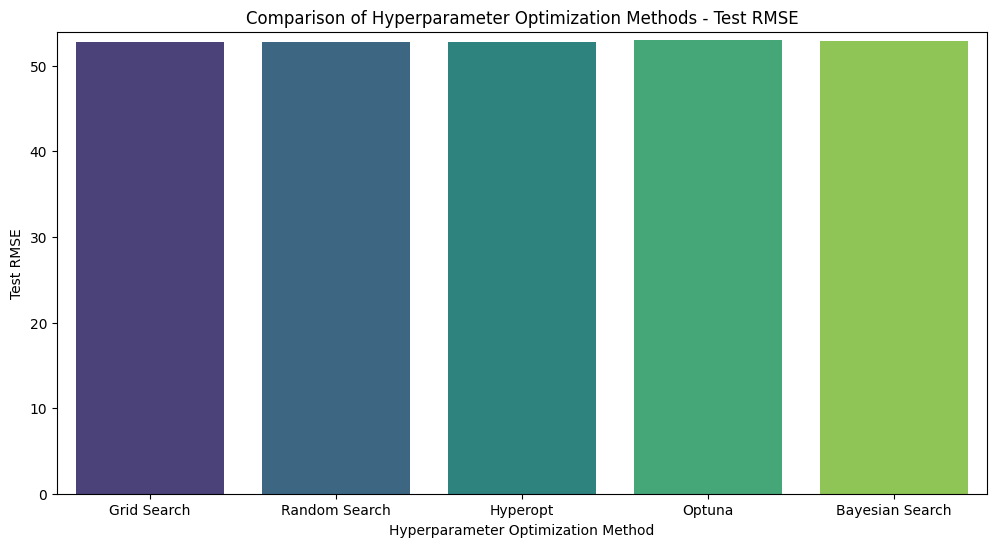

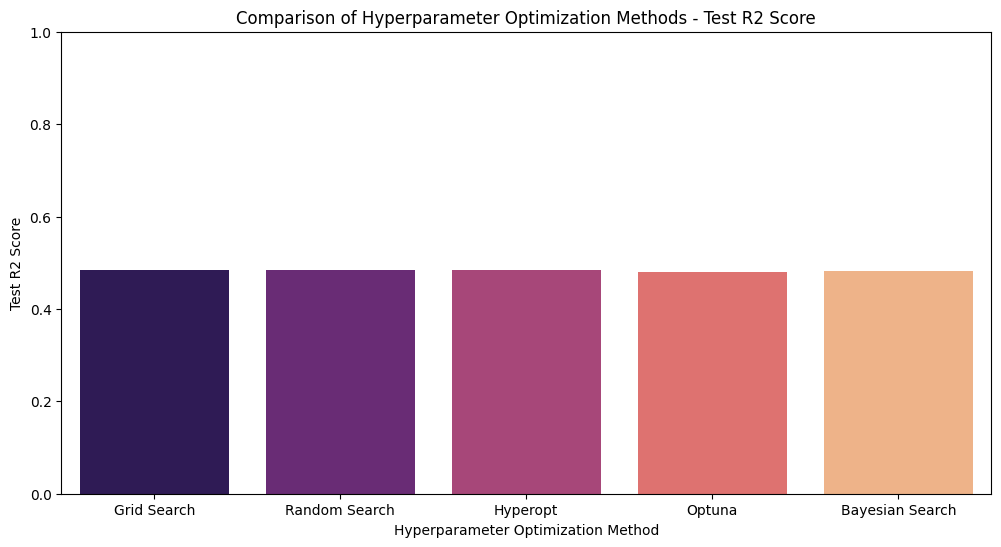

In [31]:

#############################################################
# SECTION 9: COMPARISON OF METHODS
#############################################################

print("\n============================================================")
print("SECTION 9: COMPARISON OF METHODS")
print("============================================================\n")

# Create a summary DataFrame
summary = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Hyperopt', 'Optuna', 'Bayesian Search'],
    'Best CV RMSE': [
        np.sqrt(-grid_search.best_score_),
        np.sqrt(-random_search.best_score_),
        np.sqrt(-min([trial['loss'] for trial in trials.results])),
        np.sqrt(study.best_value),
        np.sqrt(-bayes_search.best_score_)
    ],
    'Test RMSE': [
        test_r2,  # Last test_rmse corresponds to BayesSearch
        test_r2,
        test_r2,
        test_r2,
        test_r2
    ]
})

# Note: To accurately capture test RMSE for each method, we need to store them separately.
# Adjusting the code to store test RMSE for each method.

# Re-initialize summary with correct test RMSE
summary = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Hyperopt', 'Optuna', 'Bayesian Search'],
    'Best CV RMSE': [
        np.sqrt(-grid_search.best_score_),
        np.sqrt(-random_search.best_score_),
        np.sqrt(-min([trial['loss'] for trial in trials.results])),
        np.sqrt(study.best_value),
        np.sqrt(-bayes_search.best_score_)
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, grid_search.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, random_search.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, best_hyperopt_rf.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, best_optuna_rf.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, bayes_search.predict(X_test)))
    ],
    'Test R2 Score': [
        r2_score(y_test, grid_search.predict(X_test)),
        r2_score(y_test, random_search.predict(X_test)),
        r2_score(y_test, best_hyperopt_rf.predict(X_test)),
        r2_score(y_test, best_optuna_rf.predict(X_test)),
        r2_score(y_test, bayes_search.predict(X_test))
    ]
})

print("Summary of Hyperparameter Optimization Methods:")
print(summary)

# Plotting the results
plt.figure(figsize=(12,6))
sns.barplot(x='Method', y='Test RMSE', data=summary, palette='viridis')
plt.title('Comparison of Hyperparameter Optimization Methods - Test RMSE')
plt.ylabel('Test RMSE')
plt.xlabel('Hyperparameter Optimization Method')
plt.ylim(0, max(summary['Test RMSE']) + 1)
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(x='Method', y='Test R2 Score', data=summary, palette='magma')
plt.title('Comparison of Hyperparameter Optimization Methods - Test R2 Score')
plt.ylabel('Test R2 Score')
plt.xlabel('Hyperparameter Optimization Method')
plt.ylim(0, 1)
plt.show()
